# Notebook for Processing TR-XRD Data using the TRXRD Code

**Don't forget to update globals.py with detector information before running this code**

## Import Necessary Packages

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile as tf

import trxrd


%matplotlib widget

## Define Experimental Parameters

In [6]:
# Experimental Parameters and Defaults
# ============================================================
# Data and Mask Paths, Scan Name, and Filename Pattern
# ============================================================
DATA_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3") # Path to directory containing TIFF files
MASK_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif") # Path to mask file
SCAN_NAME = "BTO400nmS3_240Ksurv3" # Prefix in file name to identify relevant files, e.g. "550nm_re" etc.
SCAN_TYPE = "delay_scan" # Type of scan based on filename pattern, e.g. "delay_scan", "theta_samz", etc. Must correspond to a key in the "filename_patterns" dictionary in trxrd.py
BACKGROUND_PATH = Path(r"\\s7data\beams46\7IDC\Cotts\2025_11Exp\BlankSubstratePinkBeam\blanksubstratePinkBeam-1.0fshw-4e-09delay00004_020.tif")
SAVE_PATH = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_31.2keV\BTO400nmS3_240Ksurv3") # Path to directory where processed data will be saved, e.g. as .h5 file
# PONI file from pyFAI-calib2. Set to a Path to use PONI geometry;
# set to None to use the manual parameters below.
PONI_FILE = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\CeO2\poni_files\CeO2_calib_poni.poni") # Path to .poni file, or None

# ============================================================
# General Defaults
# ============================================================
FIGSIZE = (10, 4)
STD_FACTOR = 3
MAX_PROCESSORS = 4
DELAY_SIGN = -1 # Check file naming scheme, sometimes positives delays have "-" in front and negative have no sign so need to invert sign

# ============================================================
# Beam Stop Mask Defaults
# ============================================================
MASK_CENTER_X = 52
MASK_CENTER_Y = 1667
MASK_RADIUS = 30

# ============================================================
# Center Guess and Sampling Defaults
# ============================================================
CENTER_X = 44
CENTER_Y = 1666
DOWNSAMPLE = 2 # Downsample factor for center finding, e.g. 2 means use every other pixel, 4 means use every 4th pixel, etc.

# ============================================================
# Detector Parameters and Defaults
# ============================================================

# Detector and beam parameters
PIXEL1 = 1.72e-4                 # m, detector pixel size along rows (y)
PIXEL2 = 1.72e-4                 # m, detector pixel size along cols (x)
DISTANCE = 0.1723                 # m, sample-to-detector distance
WAVELENGTH = 0.39738514824147314e-10          # m

# Detector orientation
TILT_ANGLE = np.deg2rad(0)               # rad
TILT_PLANE_ROTATION = np.deg2rad(90)      # rad
ROT3 = 0.0                      # rad, in-plane detector rotation

# Optional corrections
POLARIZATION_FACTOR = 0.999      # e.g. 0.99 or None
DARK = None                     # 2D dark image or None
FLAT = None                     # 2D flat-field image or None

# ============================================================
# Azimuthal Averaging and Normalization Defaults
# ============================================================
UNIT = "q_A^-1" # Unit for x-axis of azimuthally averaged data, e.g. "q_A^-1" for inverse Angstroms, "2theta_deg" for degrees, etc. 
NAN_MIN = 0.35 # Minimum value for valid data, values below this will be set to NaN, e.g. 0.35 or None for no minimum threshold
NAN_MAX = None # Maximum value for valid data, values above this will be set to NaN, e.g. 1.0 or None for no maximum threshold
NORM_MIN = 4.05 # Minimum value for normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
NORM_MAX = 4.25 # Maximum value for normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold
N_POINTS = 3000 # Number of points for azimuthal averaging, e.g. 3000 or None to use all pixels

# ============================================================
# Background Subtraction Defaults
# ============================================================
BACKGROUND_NORM_MIN = 1.0 # Minimum value for background normalization, values below this will be set to this value before normalization, e.g. 0.5 or None for no minimum threshold
BACKGROUND_NORM_MAX = 1.5 # Maximum value for background normalization, values above this will be set to this value before normalization, e.g. 1.0 or None for no maximum threshold

# ============================================================
# Baseline Subtraction Defaults
# ============================================================
LAM_VAL = 1e4
P_VAL = 0.05

# ============================================================
# PDF Calcuation Defaults
# ============================================================
COMPOSITION = "BaTiO3" # Sample composition for form factor calculation, e.g. "BaTiO3" or None for no form factor correction
R_MAX = 20.0 # Maximum r value for PDF calculation, e.g. 20.0 or None for no maximum
N_R = 2000 # Number of r points for PDF calculation, e.g.
Q_MIN = 0.5 # Minimum q value for PDF calculation, e.g. 0.5 or None for no minimum
Q_MAX = 15.0 # Maximum q value for PDF calculation, e.g. 16.0 or None for no maximum
WINDOW = "lorch" # Window function for PDF calculation, e.g. "lorch", "hanning", "blackman", or None for no window
# ============================================================
# Optional Saving .dat Files
# ============================================================
SAVE_AZAV_DAT = True # Whether to save azimuthally averaged profiles as .dat files in addition to the .h5 file, e.g. True or False
# ============================================================
# Form Factor CSV File
# ============================================================
FORM_FACTOR_FILE = Path(
    r"C:\Users\lheald\Documents\Guzelturk_Lab\gued\packages\x_ray_ff\atomic_FF_coeffs_clean.csv"
)

## Define File Paths

In [7]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}-*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

sample_files = sorted(DATA_PATH.glob(f"{SCAN_NAME}-*.tif"))
sample_image = tf.imread(str(sample_files[0]))

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Build Combined Masks

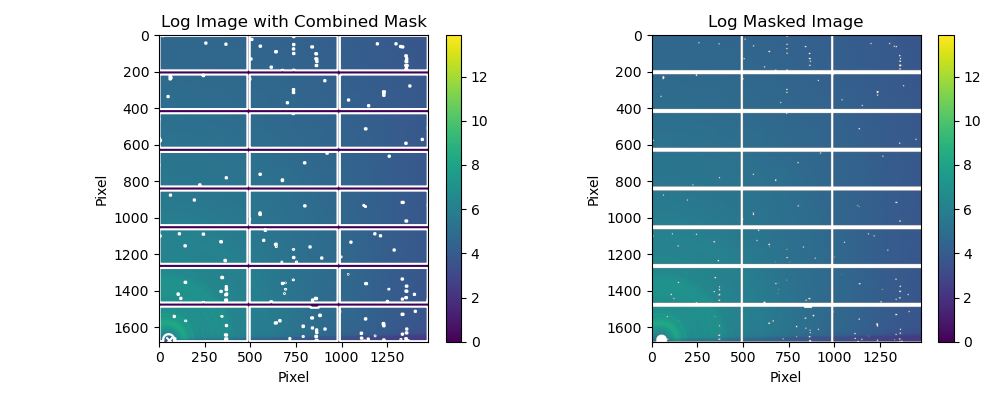

In [8]:
combined_mask = trxrd.build_combined_mask(
    sample_image.shape,
    center_xy = (MASK_CENTER_X, MASK_CENTER_Y),
    radius = MASK_RADIUS,
    detector_mask=None,
    mask_path=MASK_FILE,
    plot=True,
    example_image=sample_image,
)

## Import Images and Azimuthal Average

This can take a few minutes if you're loading in hundreds of images. Might crash with thousands of images...

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_240Ksurv3.
Integrating 884 images (streaming)...
  Completed 100/884 (11.3%)
  Completed 200/884 (22.6%)
  Completed 300/884 (33.9%)
  Completed 400/884 (45.2%)
  Completed 500/884 (56.6%)
  Completed 600/884 (67.9%)
  Completed 700/884 (79.2%)
  Completed 800/884 (90.5%)
  Completed 884/884 (100.0%)
Done integrating.


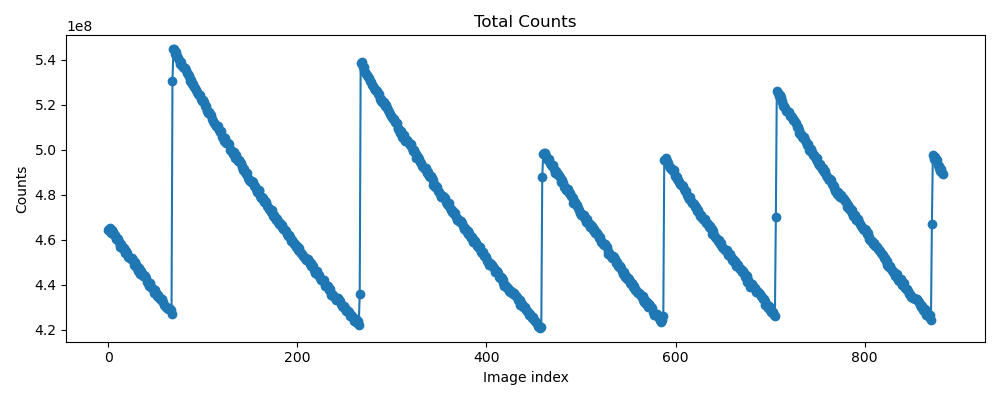

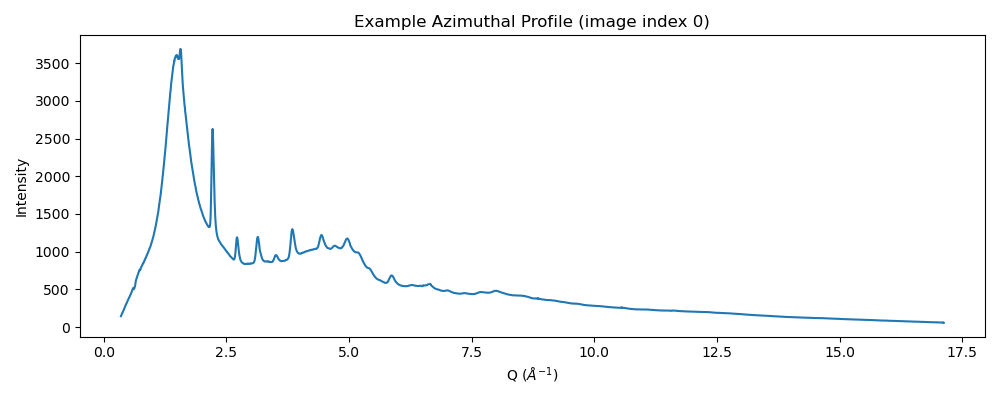

q shape: (3000,)
profiles shape: (884, 3000)
Unique delays: [-8.e-08 -5.e-09  6.e-10]


In [9]:
az_result = trxrd.get_azimuthal_average_for_image(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme=SCAN_TYPE,
    sort_key="image_number",
    delay_sign=DELAY_SIGN,
    poni_path=PONI_FILE,          # handles geometry; set to None and pass centers_xy if using manual geometry
    npt=N_POINTS,
    unit=UNIT,
    nan_radial_range=(NAN_MIN, NAN_MAX),
    integration_mask=combined_mask,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot=True,                    # plots counts vs image index
)

q         = az_result["radial"]
profiles  = az_result["profiles"]
delays    = az_result["delay"]
counts    = az_result["counts"]
fluences  = az_result["fluence"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)
print("Unique delays:", np.unique(delays))


In [10]:
az_result.keys()

dict_keys(['radial', 'profiles', 'counts', 'file_names', 'centers_used_xy', 'centers_used_yx', 'success', 'geometry', 'unit', 'radial_range', 'nan_radial_range', 'fluence', 'sample_name', 'file_name', 'delay', 'image_number'])

## Average by Delay

In [19]:
delay_avg_result = trxrd.average_profiles_by_delay(
    profiles,
    delays,
    verbose=True,
    return_dict=True,
)

mean_profiles = delay_avg_result["mean_profiles"]
unique_delays = delay_avg_result["unique_delays"]*1e9

Delay -8e-08: 295 profiles averaged
Delay -5e-09: 295 profiles averaged
Delay 6e-10: 294 profiles averaged


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:754: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [31]:
delay_avg_result.keys()

dict_keys(['unique_delays', 'mean_profiles', 'std_profiles', 'counts_per_delay', 'indices_by_delay'])

## Normalize Azimuthal Averages

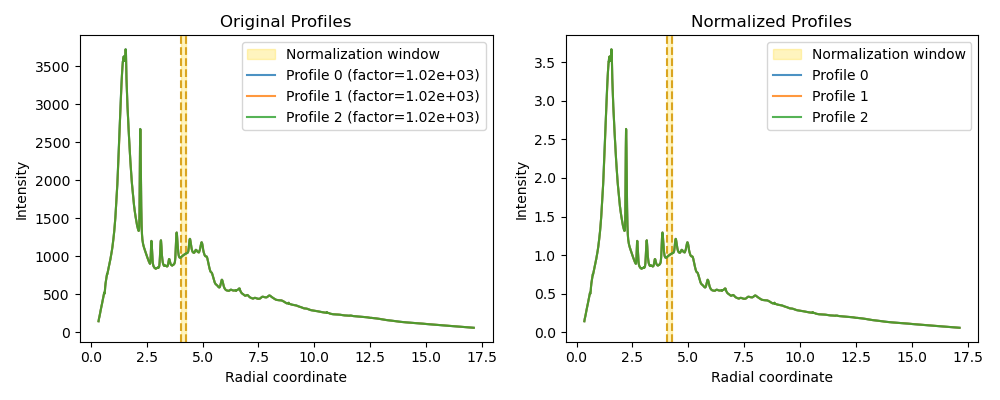

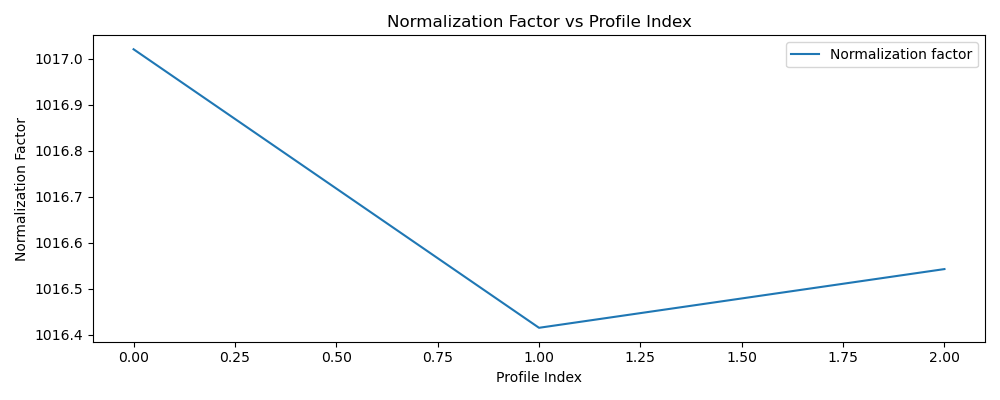

In [14]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=mean_profiles,
    norm_range=(NORM_MIN, NORM_MAX),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 1, 2],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Save as .dat Files

In [25]:
SAVE_PATH.mkdir(parents=True, exist_ok=True)

# delays = data_dict["delay"]
# # If you also want fluence, include it if available:
# fluence = data_dict.get("fluence", None)

for i, mean_profile in enumerate(profiles_norm):

    if not np.any(np.isfinite(mean_profile)):
        print(f"Skipping index {i} (all NaN)")
        continue

    filename = Path(f"{COMPOSITION}_{unique_delays[i]}ns.dat")
    output_file = SAVE_PATH / filename

    valid_mask = np.isfinite(q) & np.isfinite(mean_profile)
    data_to_save = np.column_stack((q[valid_mask], mean_profile[valid_mask]))

    header = "q (A^-1)\tI_normalized (a.u.)"

    np.savetxt(
        output_file,
        data_to_save,
        header=header,
        comments="",
    )

    print(f"Saved: {output_file.name}")

Saved: BaTiO3_-80.0ns.dat
Saved: BaTiO3_-5.0ns.dat
Saved: BaTiO3_0.6ns.dat


## Load and Prepare Background Image(s)

dict_keys(['files', 'background_stack', 'background_mean', 'background_std', 'n_images'])
Background stack shape: (1, 1679, 1475)
Background mean shape: (1679, 1475)
Integrating 1 images...


C:\Users\lheald\AppData\Local\Temp\ipykernel_40068\2878563893.py:21: RuntimeWarning: Mean of empty slice
  bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


  Completed 1/1 (100.0%)
Done integrating.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\normalization.py:266: RuntimeWarning: Mean of empty slice
  background_profile_mean = np.nanmean(background_profiles, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


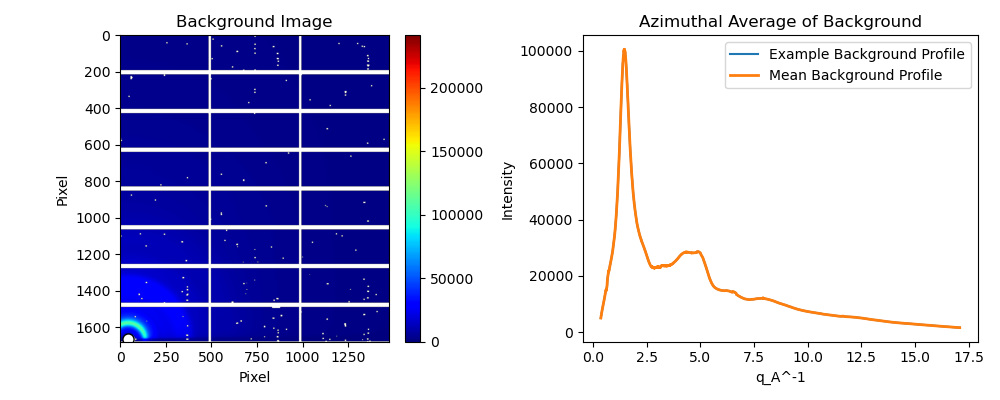

In [26]:
# Background path can be either:
# - a single tif file
# - or a folder containing many background tif files
# Load Data
bg_dict = trxrd.load_background(
    background_path=BACKGROUND_PATH,
    sort=True,
    plot=False,
)

print(bg_dict.keys())
print("Background stack shape:", bg_dict["background_stack"].shape)
print("Background mean shape:", bg_dict["background_mean"].shape)

bg_dict["background_stack"] = trxrd.apply_mask_from_bool(
    data_array=bg_dict["background_stack"],
    mask_bool=combined_mask,
)


bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# Compute background azimuthal average
bg_az_result = trxrd.compute_background_azimuthal_average(
    background_input=bg_dict["background_stack"],
    centers_xy=(CENTER_X, CENTER_Y),   # one average center in (x, y)
    unit=UNIT,
    polarization_factor=POLARIZATION_FACTOR,
    npt=N_POINTS,
    use_custom_polarization=False,
    integration_function="integrate1d",
    correct_solid_angle=False,
    plot=True,
)

q_bg = bg_az_result["radial"]
background_profile = bg_az_result["background_profile_mean"]



## Subtract Scaled Background from Images

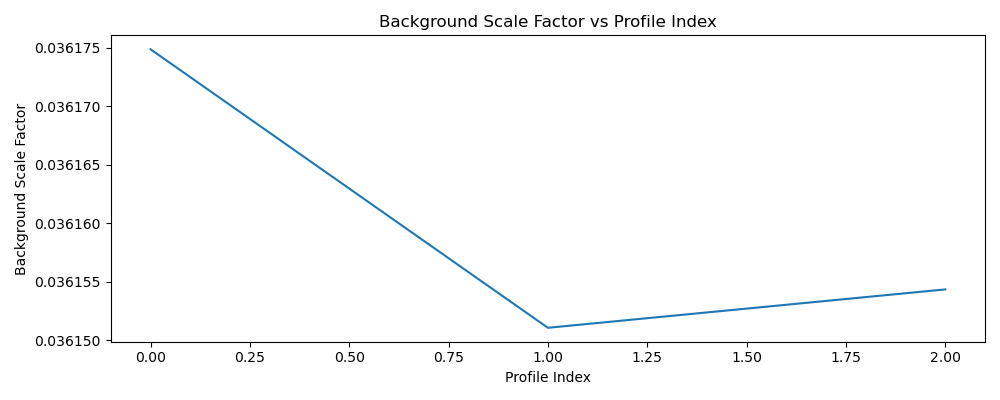

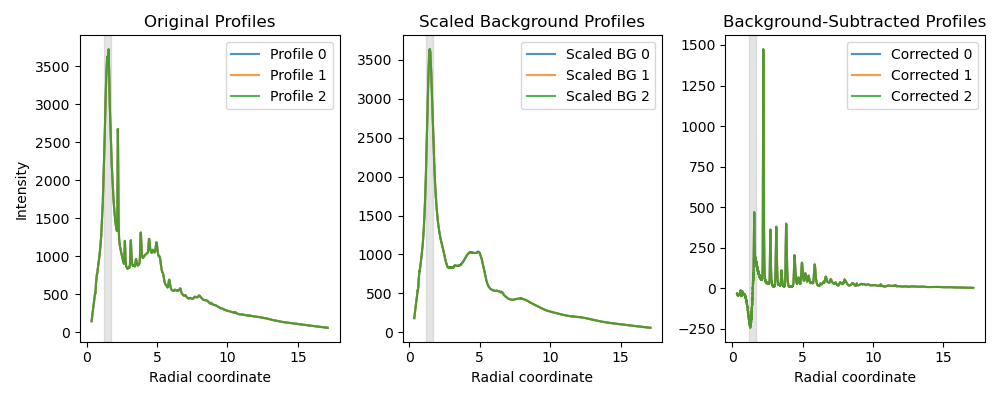

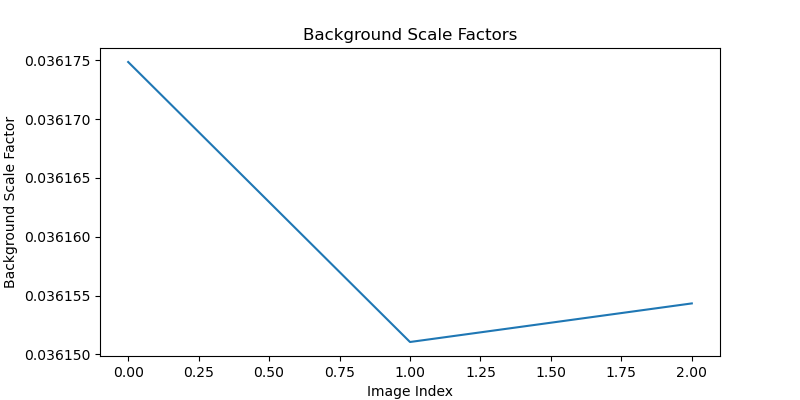

In [29]:
bgsub_result = trxrd.subtract_scaled_background_profile(
    radial=q,
    profiles=mean_profiles,
    background_profile=background_profile,
    norm_range=(1.2, 1.7),   # example region; adjust as needed
    mode="mean",
    scale_method="ratio",
    plot=True,
    plot_scale_factors=True,
    plot_indices=[0, 1, 2],
    return_dict=True,
)

profiles_bgsub = bgsub_result["corrected_profiles"]
baselines = bgsub_result["scaled_background_profiles"]

# Inspect Scaling Factors
plt.figure(figsize=(8, 4))
plt.plot(bgsub_result["scale_factors"])
plt.xlabel("Image Index")
plt.ylabel("Background Scale Factor")
plt.title("Background Scale Factors")
plt.show()

## Save Background

In [30]:
df = pd.DataFrame({
    "q": q_bg,
    "I(q)": baselines[0]/1000   # example: save the baseline for the first image
})

df.to_csv(
    f"{SAVE_PATH}/{COMPOSITION}_background.dat",
    sep=" ",
    index=False
)

## Make Reference Profile

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:834: RuntimeWarning: Mean of empty slice
  reference_profile = np.nanmean(ref_group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


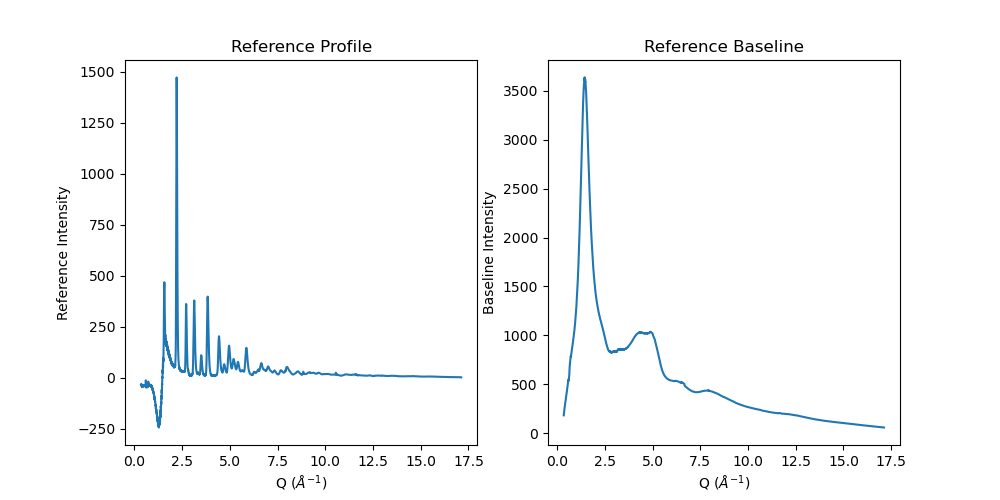

In [32]:
ref_result = trxrd.make_reference_profile(
    profiles=profiles_bgsub,
    delays=unique_delays,
    reference_selector=None,
    return_dict=True,
)

ref_baseline = trxrd.make_reference_profile(
    profiles=baselines,
    delays=unique_delays,
    reference_selector=None,
    return_dict=True,
)

reference_profile = ref_result["reference_profile"]
reference_baseline = ref_baseline["reference_profile"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q, reference_profile)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Reference Intensity")
plt.title("Reference Profile")

plt.subplot(1, 2, 2)
plt.plot(q, reference_baseline)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Baseline Intensity")
plt.title("Reference Baseline")

plt.show()

## Compute Difference Profiles

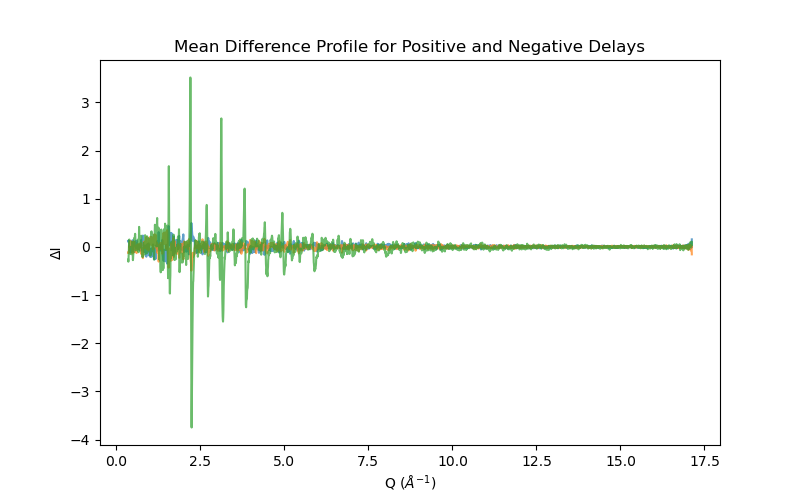

In [33]:
delta_result = trxrd.compute_delta_profiles(
    profiles=profiles_bgsub,
    reference_profile=reference_profile,
    mode="subtract",
    return_dict=True,
)

baseline_results = trxrd.compute_delta_profiles(
    profiles=baselines,
    reference_profile=reference_baseline,
    mode="subtract",
    return_dict=True,
)

delta_profiles = delta_result["delta_profiles"]
delta_baselines = baseline_results["delta_profiles"]


plt.figure(figsize=(8, 5))
for delay in np.unique(unique_delays):
    mean_profile = np.mean(delta_profiles[np.where(unique_delays == delay)[0]], axis=0)
    plt.plot(q, mean_profile, alpha=0.7, label=f"Delay {delay} ps")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("ΔI")
plt.title("Mean Difference Profile for Positive and Negative Delays")
#plt.legend()
plt.show()

## Plot Lineouts 

c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


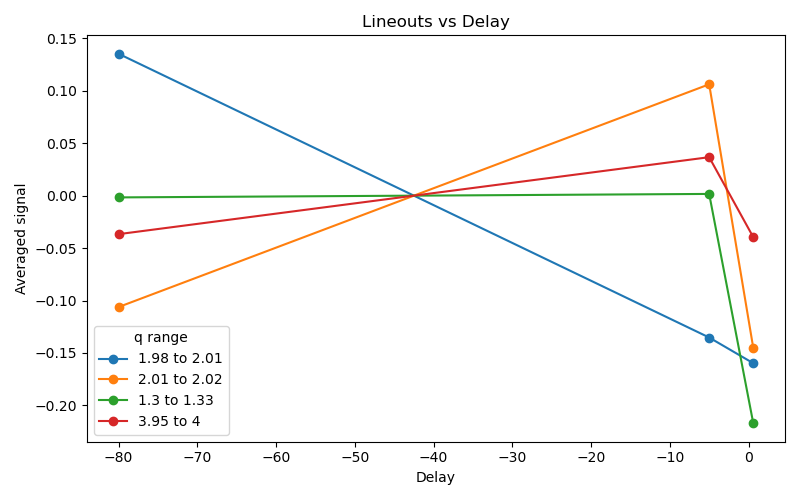

In [34]:
lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_profiles,
    delays=unique_delays,
    q_ranges=[(1.98, 2.01), (2.01, 2.025), (1.3, 1.33), (3.95, 4.0)],
    average_mode="mean",
    error_type="sem",
    plot=True,
    return_dict=True,
)

## Check Baseline per Delay

Delay -80.0: 1 profiles averaged
Delay -5.0: 1 profiles averaged
Delay 0.6: 1 profiles averaged


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd\analysis.py:754: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


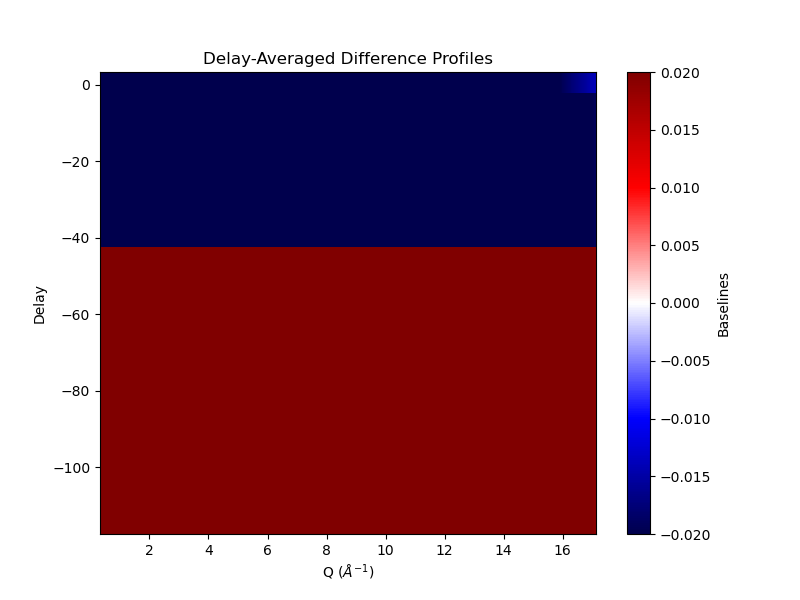

In [35]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_baselines,
    delays=unique_delays,
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_bkgs = delay_result["mean_profiles"]
std_bkgs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_bkgs, shading="auto", cmap="seismic")
plt.colorbar(label="Baselines")
plt.clim(-0.02, 0.02)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()